In [1]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

In [6]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
96,5.7,2.9,4.2,1.3,1
88,5.6,3.0,4.1,1.3,1
105,7.6,3.0,6.6,2.1,2
107,7.3,2.9,6.3,1.8,2
114,5.8,2.8,5.1,2.4,2


In [7]:
df = df[['sepal_length', 'petal_length', 'species']]

In [8]:
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [9]:
x = df.drop('species', axis=1)
y = df['species']


In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [32]:
clf = LogisticRegression(multi_class='multinomial')
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [33]:
print(accuracy_score(y_test, y_pred))

0.9666666666666667


In [34]:
pd.DataFrame(confusion_matrix(y_test, y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [35]:
query = np.array([[5.1, 3.5]])
clf.predict_proba(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.11479481, 0.87466602, 0.01053917]])

In [36]:
clf.predict(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

# Plotting the regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


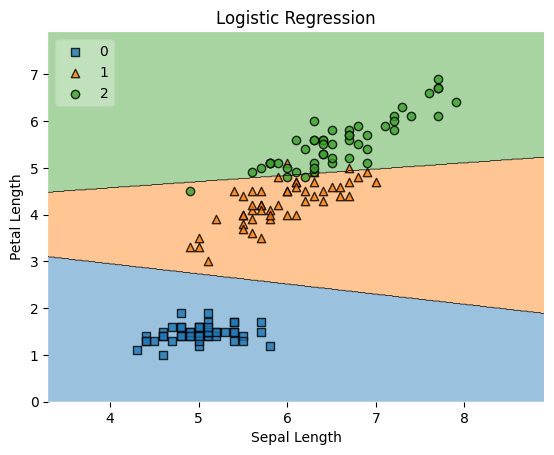

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values, y.values, clf=clf, legend=2)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Logistic Regression')
plt.show()

trying polynomial logistic regression

In [48]:
from sklearn.preprocessing import PolynomialFeatures


In [49]:
poly = PolynomialFeatures(degree=3)
x_trf = poly.fit_transform(x)

In [50]:
x_trf

array([[  1.   ,   5.1  ,   1.4  , ...,  36.414,   9.996,   2.744],
       [  1.   ,   4.9  ,   1.4  , ...,  33.614,   9.604,   2.744],
       [  1.   ,   4.7  ,   1.3  , ...,  28.717,   7.943,   2.197],
       ...,
       [  1.   ,   6.5  ,   5.2  , ..., 219.7  , 175.76 , 140.608],
       [  1.   ,   6.2  ,   5.4  , ..., 207.576, 180.792, 157.464],
       [  1.   ,   5.9  ,   5.1  , ..., 177.531, 153.459, 132.651]])

In [51]:
from sklearn.model_selection import cross_val_score
clf1 = LogisticRegression(multi_class='multinomial', max_iter=1000)

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x_trf, y, test_size=0.2, random_state=2)

In [54]:
clf = LogisticRegression(multi_class='multinomial')
clf.fit(x_train, y_train)
y_pred1 = clf.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [58]:
print(accuracy_score(y_test, y_pred1))

0.9666666666666667
